## The Responsible Business Simulator (tRBS)
This notebook demonstrates the steps of the tRBS model.
The process is structured into three main chapters:

- Chapter 1: Setup
- Chapter 2: The seven-step tRBS framework, based on the book *Responsible Business Decision-Making (2023, A. Roobeek, J. de Swart, M. van der Plas)*.
- Chapter 3: (Optional) Save your case

## Chapter 1 - Set up

In this chapter, we guide you through the setup process required to work with the Responsible Business Simulator (tRBS) model.

Throughout the steps of tRBS, we use the following functions (listed in the order they appear in this notebook), which are in the package called `vlinder`:

- `build()`: Loads case data from files into input_dict.
- `visualize()`: Generates a table, bar chart, or dependency graph for the requested data.
- `evaluate()`: Calculates the key output values.
- `appreciate()`: Calculates the weighted, appreciated key output values.
- `optimize()`: Identifies an optimal decision-maker distribution for a scenario and adds it to the case.
- `modify()`:   Adjusts a theme, key output, or scenario weight.
- `transform()`: Exports the case data to another format.
- `make_report()`: Creates a PDF report for a scenario (requires completion all seven tRBS steps).


We will start with installing the `vlinder` package.

When using Colab, you may encounter an error the first time you run the code cell below. From the notebook menubar, open 'Runtime', then choose 'Restart session'.

In [1]:
# Install the python package vlinder
!pip install vlinder


[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


(OPTIONAL) If you have created your own case, you can upload your .xlsx file to Files (located on the left side of your Notebook). You can also use .csv or .json. When using Colab, follow these steps; replace 'name' with your case name and 'file_extension' with its file type:
1. In Files, create a folder named 'name'
2. Inside the 'name' folder, create a folder named 'file_extension'
3. Inside 'file_extension' folder, upload your case file named 'name.file_extension'.

As an example, you might have a folder structure like this: Files > Winewiser > xlsx > Winewiser.xlsx

*Important*: ensure that folder and file names, including spacing and capitalization, match exactly.

Now that you have installed the `Vlinder` package, import its classes and functions. And import other utility functions required for this notebook.

In [2]:
# Import all classes and functions from the vlinder package
from vlinder import *

# Import other utility functions required for this notebook
import shutil
from pathlib import Path
import pandas as pd

Next, select a simulation case (default: 'Beerwiser') and create your case. Finally, use the `build()` function to load the case data and initialize all model components.

In [3]:
# Select a case.  By default we use the Beerwiser case and xlsx file. If you use your own case, fill here in your name and file.
case_name = 'Refugee'

# Check whether you use your own case or demo case
if Path(f'{case_name}').exists():
  # Delete temporary checkpoints of Google Colab
  shutil.rmtree(Path(f'{case_name}/.ipynb_checkpoints'), ignore_errors=True)

  # Retrieve your own case from the local Google Colab
  case = TheResponsibleBusinessSimulator(name=case_name, file_path=Path.cwd(), file_extension='xlsx')

else:
  # Retrieve your demo case from the Vlinder package
  case = TheResponsibleBusinessSimulator(name=case_name, file_extension='xlsx')

# Build all necessary elements for a generic tRBS case
case.build()

Creating 'Refugee'
Hierarchy calculated in 67 iterations


If you created your own case, you may encounter an error during the process.
In such cases, you will need to adjust the Excel file before you can proceed.
The error message will provide an indication of what needs to be corrected.
If the error message is *Template Error: Incorrect path*, check that you uploaded your case file to Files correctly.

If a warning occurs, you may still proceed. However, it is generally recommended
to resolve the warning to ensure the accuracy and stability of the results.

A common issue is that names, spaces and capitalizations do not match between sheets. For example, one sheet may use the key output *Accidents reduction* while another uses *Accidents Reduction*. Make sure the text matches exactly.

## Chapter 2 - Seven-step tRBS framework
In this chapter, we guide you through the framework’s seven steps that lead to a transparant strategic choice grounded in data and dialogue.

### Step 1 - Strategic challenge

In this step, we describe the strategic challenge that requires a decision and the stakeholders involved.

In [4]:
# Print the strategic challenge
print(case.input_dict['case_text_element_value'][0])

The International Organisation for Migration (2016) counted 1,011,712 migrants and refugees that crossed the southern border of the European Union in 2015, which some have dubbed a ‘refugee crisis’. A distinction can be made between refugees and economic migrants. Economic migrants are, contrary to refugees, not forced to leave their country because of war or another humanitarian crisis, but move from their own country to a new country in order to find work or have a better standard of living. Europe currently has to cope with both. A (temporary) residence permit that grants asylum is generally only awarded to refugees. This permit is a ticket for integration in society, for work and education. The strategic challenge we face is determining how to accommodate refugees effectively.


### Step 2 - Key outputs

In this step, we describe the key outputs, or KPIs, on which the stakeholders will base their decision. These key outputs can be divided into themes, for example people, planet and profit.

You can use the `visualize()` function to display the key output across the different themes.

In [5]:
# Visualize the key outputs and its theme
case.visualize('table', 'key_outputs_theme')

,key_outputs,key_output_theme
0,Quality of life Ukrainians,Society
1,Quality of life other refugees,Society
2,Quality of life inhabitants,Society
3,Unemployment reduction Ukrainians,Society
4,Unemployment reduction other refugees,Society
5,Unemployment reduction inhabitants,Society
6,Economic impact,Economy


### Step 3 - Internal variable inputs and decision maker options

In this step, the internal variable inputs (IVIs) and decision‑maker options (DMOs) are defined. IVIs are the actions available to the decision maker, for example budget allocations, percentage allocations, binary choices, or combinations of these. In addition, the DMOs define the possible combinations of the IVIs. Essentially, the model allows the decision maker to create any number of DMOs by combining the available IVIs in different ways.

You can use the visualize() function to display values of the IVIs across the different DMOs.

In [6]:
# Visualize the IVIs distribution in each DMO
case.visualize('table', 'decision_makers_options')

,Internal variable input,Employment & Education,Employment & Language,Employment & Sports,Mix all interventions,Sports & Language
0,Access to transport,0.00,0.00,0.00,1.3M,0.00
1,Education after 18,3.2M,0.00,0.00,1.3M,0.00
2,Employment,3.2M,3.2M,3.9M,1.3M,0.00
3,Language and integration course,0.00,3.2M,0.00,1.3M,3.9M
4,Sports and association,0.00,0.00,2.6M,1.3M,2.6M


### Step 4 - Scenarios

In this step, the external variable inputs (EVIs) and scenarios are defined. EVIs are not under the decision maker's control and introduce external uncertainty that affects the outcome of the decision. A scenario is defined by assigning a single value to all the EVIs. These values are collected from literature, historical data, expert opinions, or a combination of these sources.


You can use the `visualize()` function to display the values of the EVIs across the different scenarios.

In [7]:
# Visualize the EVIs per scenario.
case.visualize('table', 'scenarios')

,External variable input,Base case,Labour optimistic,Labour pessimistic
0,Min. investment in language and integration for full employment effect,2.6M,2.6M,5.2M
1,Reduction employment effect,0.70,0.70,0.70
2,Yearly salary education after 18,43.5K,37.0K,50.1K
3,Yearly salary employment creating and matching,30.5K,26.8K,34.1K
4,Yearly salary language and integration,34.9K,27.1K,40.8K
5,Yearly salary sports and associations,25.3K,21.4K,34.3K


### Step 5 - Simulation model

In this step, the simulation model is validated in the form of a set of dependencies that compute key outputs based on the DMOs and scenarios.

This validation consits of 4 substeps:
- 5.1 -  Visualize the fixed inputs.
- 5.2 -  Visualize the dependencies through the dependency graph.
- 5.3 -  Apply the `evaluate()` function and calculate the *key output values*.
- 5.4 - Apply the `appreciation()` function and calculate the *appreciated key output values*.
- 5.5 - (Optional) Apply the `modify()` function to choose the key output weights within one theme.


#### 5.1 Fixed inputs

Fixed inputs are not modified internally or externally during the decision-making process. These inputs are in addition to the IVIs and EVIs and are often needed to model the relationship between variable inputs and the key outputs. The fixed input values are collected from literature, historical data, expert opinions, or a combination of these sources.

You can use the `visualize()` function to display the values of the fixed inputs.


In [8]:
# Visualize the fixed inputs
case.visualize('table', 'fixed_inputs')

,fixed_inputs,fixed_input_value
0,Effect of unemployment reduction other refugees on income other refugees,0.81
1,Effect of unemployment reduction Ukrainians on income Ukrainians,0.81
2,Effect of unemployment reduction inhabitants on income inhabitants,0.37
3,Effect of unemployment reduction other refugees on social trust other refugees,0.01
4,Effect of unemployment reduction inhabitants on QoL inhabitants,0.27
5,Effect of unemployment reduction other refugees on QoL other refugees,0.27
6,Effect of unemployment reduction Ukrainians on QoL Ukrainians,0.27
7,Effect of health Ukrainians on quality of life Ukrainians,1.12
8,Effect of language acquisition Ukrainians on income Ukrainians,0.15
9,Effect of language acquisition Ukrainians on unemployment reduction Ukrainians,0.23


#### 5.2 Dependency graph

Dependencies are the relationships between the key outputs (step 2) and the other model elements:
1. IVIs (step 3);
2. EVIs (step 4);
3. fixed inputs (step 5.1);
4. intermediates, which are often generated when breaking down complex formulas.

You can use the `visualize()` function with the *dependency_graph* option to display the dependency graphs for all key outputs. By default, the dependency graph for the first key output (index 0) is shown. Optionally, you can type the hard‑coded name of a key output.

When using Colab, the dependency graph (HTML file) can be found on the toolbar on the left side under 'Files' > 'reports' > 'dependency_graphs'. Download the file and open it in a new browser tab.

Read the graph from left to right: the inputs are the nodes on the far left, the intermediates in the middle, and the key ouput on the far right, showing how each node depends on the previous ones to produce the final key output.

In [9]:
# Visuzualize the dependency graph. By default we show the the first key output.
case.visualize('dependency_graph', case.input_dict['key_outputs'][0], max_gen=20)

UnicodeEncodeError: 'charmap' codec can't encode characters in position 263607-263621: character maps to <undefined>

#### 5.3 Key output values

Now that you have a decent setup of your case, you can use the evaluate() function to calculate all key output values from the dependencies for **all decision makers options** and **all scenarios**.

You can use the `visualize()` function to visualize key output values. In default, we show the values for the first scenario (index 0). Optionally, you can type in the hard coded name of the scenario.


In [10]:
# Calculate the key output values
case.evaluate()

# Visualize the calculated key output values. By default we show the the first scenario.
case.visualize('table', 'key_outputs', scenario=case.input_dict['scenarios'][0])

- Evaluated 'Base case' successfully for all decision makers options!
- Evaluated 'Labour optimistic' successfully for all decision makers options!
- Evaluated 'Labour pessimistic' successfully for all decision makers options!


####5.4 Appreciated key output values

Now that you have calculated the key outputs, you can use the `appreciate()` function to appreciate and weight all key output values.

First, the function converts the key output values into appreciations, i.e. normalized values from 0 to 100 for each key output, by applying a linear or nonlinear transformation using minimum and maximum bounds. These bounds can be entered manually or computed automatically as the minimum and maximum of that key output across **all decision‑maker options** and **all scenarios**.

Second, the function transforms the appreciations into weighted appreciated key outputs by applying the initially defined key output and theme weights. This yields, again a normalized score from 0 to 100, but now for each decision‑maker option (DMO).

You can use the `visualize()` function to display the **appreciated key output values**. By default, the values for the first scenario (index 0) are shown. Optionally, you can type the hard‑coded name of a scenario.

In [11]:
# Appreciate and weight the key output values
case.appreciate()

# Visualize the appreciated key output values in a table. By default we show the the first scenario.
case.visualize('table', 'appreciations', scenario=case.input_dict['scenarios'][0])

Key output values have been processed | Appreciated, weighted & aggregated


#### 5.5 (Optional) Modify key output weights

In this step you assign weights to individual key outputs.

With the `modify()` function you can adjust key output weights. By default, we modify the first weight (index 0). Optionally, you can type the hard‑coded name of the key output.

In [12]:
# Retrieve the key output names and their current weights before modification
key_outputs = case.input_dict['key_outputs']
current = list(case.input_dict['key_output_weight'])

# Modify the key output weights. By default we modify the first key output to a score of 3.
case.modify('key_output_weight', case.input_dict['key_outputs'][0], 3)

# Retrieve the new key output weights after modification
new = case.input_dict['key_output_weight']

# Print the current en new key output weights
print(pd.DataFrame({'Key_output': key_outputs, 'Current weight': current, 'New weight': new}).to_string(index=False))

The weight for Quality of life Ukrainians in key_output_weight is changed from 1 to 3.
                           Key_output  Current weight  New weight
           Quality of life Ukrainians               1           3
       Quality of life other refugees               1           1
          Quality of life inhabitants               1           1
    Unemployment reduction Ukrainians               1           1
Unemployment reduction other refugees               1           1
   Unemployment reduction inhabitants               1           1
                      Economic impact               1           1


In [13]:
# Calculate the key output values
case.evaluate()

# Appreciate and weight the key output values
case.appreciate()

- Evaluated 'Base case' successfully for all decision makers options!
- Evaluated 'Labour optimistic' successfully for all decision makers options!
- Evaluated 'Labour pessimistic' successfully for all decision makers options!
Key output values have been processed | Appreciated, weighted & aggregated


### Step 6 - Strategic priorities

In this step, you assign weights to the themes to reflect your strategic priorities. This consists of three substeps:
-   6.1 - Apply the `appreciation()` function and calculate the *weighted appreciated key output values*.
-   6.2 - Apply the `modify()` function to choose your theme weights.
-   6.3 - Apply the `optimize()` function to search for the best DMO for a specific scenario

#### 6.1 Weigh themes

You can use the `visualize()` function to display the **weigthed appreciated key output values** in the *table* and *barchart* options. By default, the values for the first scenario (index 0) are shown. Optionally, you can type the hard‑coded name of a scenario.

The table and barchart below, show the weigthed appreciated values after applying the key‑output weights (step 5.5) and predefined theme weights.

In [14]:
# Visualize the weighted appreciated key output values in a table. By default we show the the first scenario.
case.visualize('table', 'weighted_appreciations', scenario=case.input_dict['scenarios'][0])

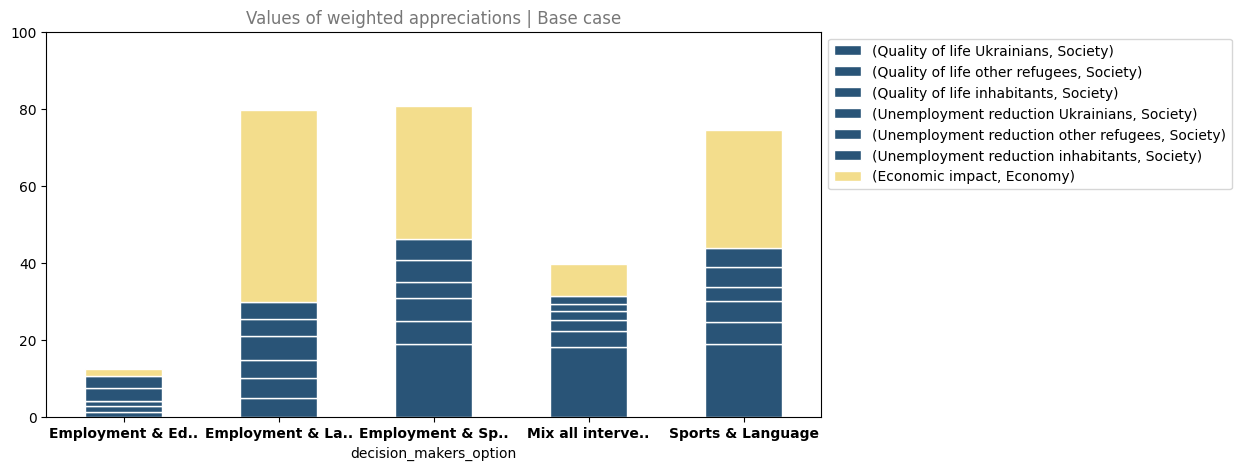

In [15]:
# Visualize the weighted appreciated key output values in a barchart. By default we show the the first scenario.
case.visualize('barchart', 'weighted_appreciations', scenario=case.input_dict['scenarios'][0])

#### 6.2 Modify theme weights
When you look at the barchart in step 6.1, watch for themes that could change the result: if increasing the weight of a single theme would make a different DMO the top scorer, that theme is a **game changer**. You can test this by raising the theme’s weight.

With the `modify()` function you can adjust theme weights to match the strategic priorities. By default, we modify the first theme weight (index 0). Optionally, you can type the hard‑coded name of the theme.

If there are no game changers, a stakeholder discussion about strategic priority is redundant, since no feasible reweighting of themes would change the highest ranked DMO.


---


For example, in the Beerwiser case the DMO "Equal spread" is the winner with the predefined theme weigths. From the barchart in step 6.1 you can identify three game changers:
1. People, increasing this theme weight makes "Focus on training" the optimal DMO.
2. Planet, increasing this theme weight makes "Focus on water recycling" the optimal DMO.
3. Planet, increasing this theme weight also makes "Focus on water recycling" the optimal DMO.


---

In [16]:
# Retrieve the theme names and their current weights before modification
themes = case.input_dict['themes']
current = list(case.input_dict['theme_weight'])

# Modify the theme weights. By default we modify the first theme to a score of 3.
case.modify('theme_weight', case.input_dict['themes'][0], 3)

# Retrieve the new theme weights after modification
new = case.input_dict['theme_weight']

# Print the current en new theme weights
print(pd.DataFrame({'Theme': themes, 'Current weight': current, 'New weight': new}).to_string(index=False))

The weight for Economy in theme_weight is changed from 1 to 3.
  Theme  Current weight  New weight
Economy               1           3
Society               1           1


After you have modified the theme weight(s) to match your strategic priorities, use the `appreciate()` function to re-weight the key output values.

You can use the `visualize()` function to display the weighted appreciated key outputs. By default, we show the weighted, appreciated key outputs for the first scenario (index 0). Optionally, you can type the hard‑coded name of a scenario.

---


For example, in the Beerwiser case when increasing the theme weight of "Planet", as predicted in step 6.1, the optimal DMO now is "Focus on water recycling".


---

- Evaluated 'Base case' successfully for all decision makers options!
- Evaluated 'Labour optimistic' successfully for all decision makers options!
- Evaluated 'Labour pessimistic' successfully for all decision makers options!
Key output values have been processed | Appreciated, weighted & aggregated


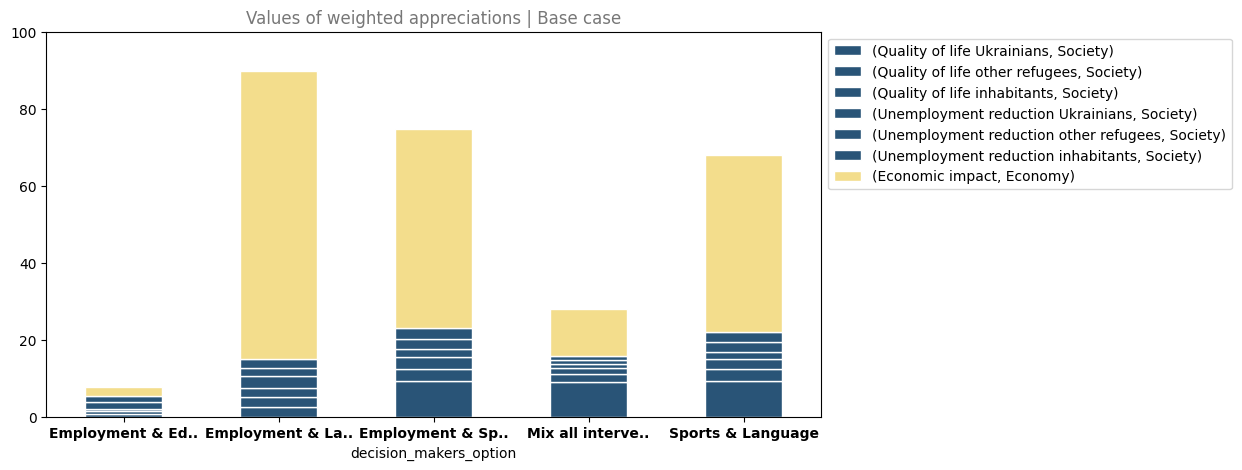

In [17]:
# Calculate, appreciate and weight the key outputs to your new theme weights
case.evaluate()
case.appreciate()

# Visualize the weighted appreciated key outputs in a barchart
case.visualize('barchart', 'weighted_appreciations', scenario=case.input_dict['scenarios'][0], stacked=True)

#### 6.3 (Optional) Optimize DMOs

After setting your priorities, you can use the `optimizer()` function to identify the optimal DMO. Here, optimal means that for a given scenario there is no budget allocation that yields a higher weighted appreciation.
The optimizer uses AI to identify this DMO; depending on your GPU, the process typically takes around *two minutes*. By default, we optimize the first scenario (index 0). Optionally, you can type the hard‑coded name of a scenario.

You can use the `visualize()` function to display budget allocation for each DMO, including the newly optimized DMO.

Moreover, if the optimizer cannot find a DMO with a higher score, it returns the current top-scoring DMO as the optimized result.

Currently the optimizer only supports full budget-allocation cases. If the user has entered a name for the optimal DMO in the configuration sheet of the Excel workbook, that signals a budget-allocation case.

---


For example, in the Beerwiser case, optimizing the "Base case" scenario yields a slight increase in appreciated value relative to the initially highest-ranked DMO "Focus on water recycling".


---

In [ ]:
# Check wheter the optimized DMO name is given
if case.input_dict['configuration_value'][1] is not None:

  # Optimize your case by seaching for the best DMO. By default we optimize over the first scenario.
  optimized_scenario = case.input_dict['scenarios'][0]
  case.optimize(optimized_scenario)

else:
  print("The optimal DMO name is not defined in the configuration sheet; this case can not be optimized.")

In [ ]:
# Visualize the budget allocation for each DMO, including the optimized DMO.
case.visualize('table', 'decision_makers_options')

Now that you have found the optimal DMO and added it to your case, you can use `evaluate()` and `appreciate()` functions again to calculate the weighted, appreciated key outputs for each DMO for the selected scenario.

In [ ]:
# Calculate the key output values
case.evaluate()

# Appreciate and weigh the key output values
case.appreciate()

# Visualize the weighted appreciated key outputs in a barchart
case.visualize('barchart', 'weighted_appreciations', scenario=optimized_scenario, stacked=True)

### Step 7 - Risk appetite

#### 7.1 Weigh scenarios

You can use the `visualize()` function to display the **weigthed appreciated scenarios**. The barchart below, shows the weigthed appreciated scenario's after applying the predefined scenario weights.

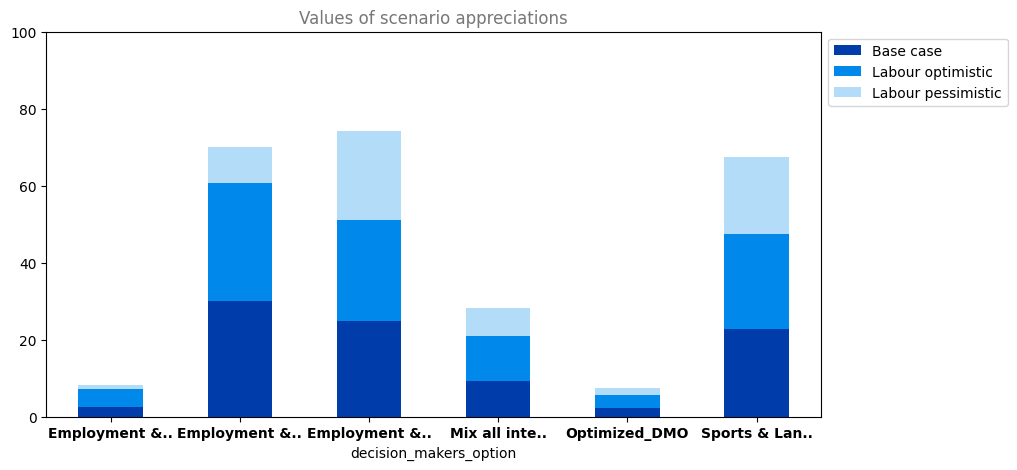

In [22]:
# Visualize the weighted appreciated key outputs in a table.
case.visualize('barchart', 'scenario_appreciations', stacked=True)

#### 7.2 Modify scenario weights
When you look at the barchart in step 7.1, watch for scenario's that could change the result: if increasing the weight of a single scenario would make a different DMO the top scorer, that scenario is a **game changer**. You can test this by raising the scenario’s weight.

With the `modify()` function you can adjust scenario weights to match the risk appetite. By default, we modify the first scenario weight (index 0). Optionally, you can type the hard‑coded name of the scenario.

If there are no game changers, a stakeholder discussion about risk appetite is redundant, since no feasible reweighting of scenario's would change the highest ranked DMO.

---

For example, in the Beerwiser case the "Optimized_DMO" (note: this DMO is optimized over only the "Base case" scenario) is the optimal DMO, regardless of whether the weights of other scenarios increase.

---


In [23]:
# Retrieve the scenario names and their current weights before modification
scenarios = case.input_dict['scenarios']
current = list(case.input_dict['scenario_weight'])

# Modify the scenario weights. By default we modify the first scenario weight to 3.
case.modify('scenario_weight', case.input_dict['scenarios'][0], 3)

# Retrieve the new scenario weights after modification
new = case.input_dict['scenario_weight']

# Print the current en new scenario weights
print(pd.DataFrame({'Scenario': scenarios, 'Current weight': current, 'New weight': new}).to_string(index=False))

The weight for Base case in scenario_weight is changed from 1 to 3.
          Scenario  Current weight  New weight
         Base case               1           3
 Labour optimistic               1           1
Labour pessimistic               1           1


After you have modified the scenario weight(s) to match your risk appetite, use the `appreciate()` function to re-weight the key output values.

You can use the `visualize()` function to display the weighted appreciated scenarios.

---


For example, in the Beerwiser case when increasing the scenario weight of "Base case", as predicted in step 7.1, the optimal DMO now remains "Optimized_DMO".


---

- Evaluated 'Base case' successfully for all decision makers options!
- Evaluated 'Labour optimistic' successfully for all decision makers options!
- Evaluated 'Labour pessimistic' successfully for all decision makers options!
Key output values have been processed | Appreciated, weighted & aggregated


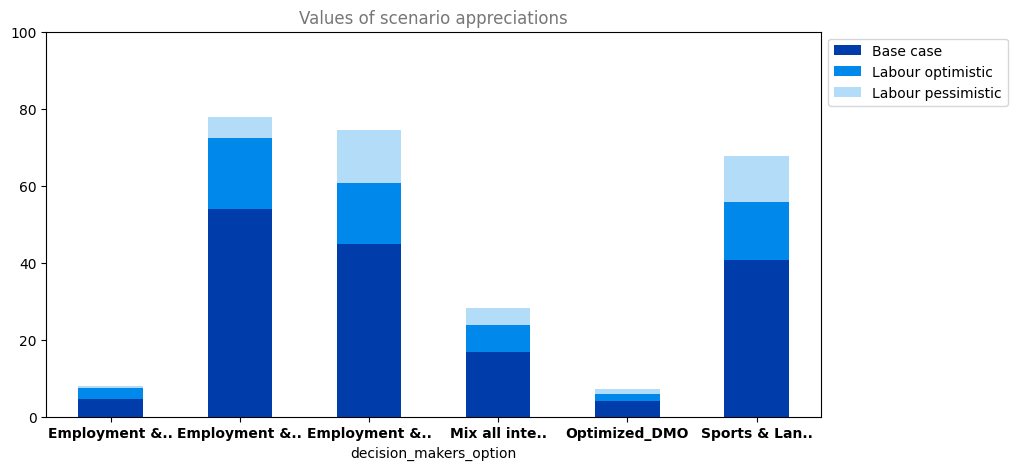

In [24]:
# Calculate the key output values
case.evaluate()

# Appreciate and weigh the key output values
case.appreciate()

# Visualize the weighted appreciated key outputs in a barchart
case.visualize('barchart', 'scenario_appreciations', stacked=True)

We can also visualize the underlying weights as pie charts — showing the relative importance of each theme, scenario, or key output.

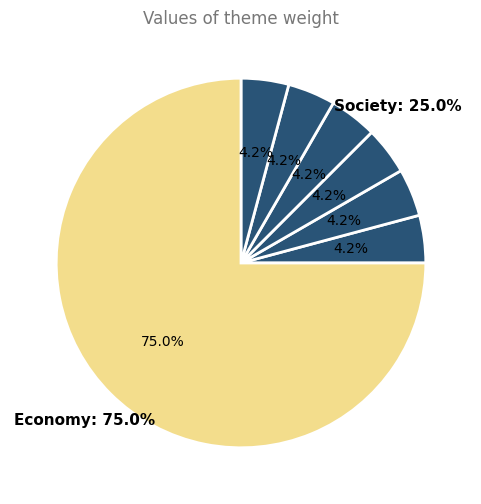

In [25]:
# Visualize the theme weights in a piechart
case.visualize('piechart', 'theme_weight')

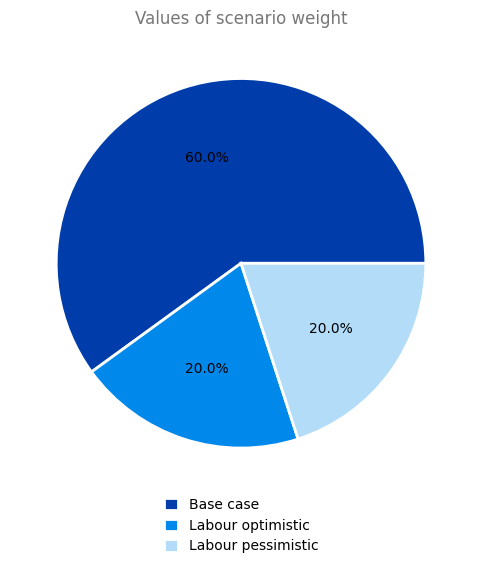

In [26]:
# Visualize the scenario weights in a piechart
case.visualize('piechart', 'scenario_weight')

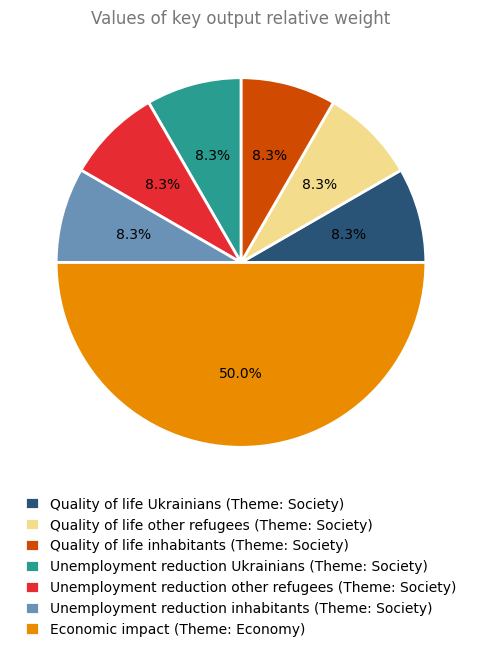

In [27]:
# Visualize the relative weight of each key output in a piechart
case.visualize('piechart', 'key_output_relative_weight')

## Chapter 3 - (Optional) Save your case

When you finished your case you can save your (new) case in a 'xlsx', 'json' or 'csv' format. The `transform()` function creates a named as the file extension with the 'data' folder and stores this at the provided location. In default, we use the 'xlsx' file extension and store it in the current Files folder.

In [ ]:
#Save your file. In default, we use xlsx.
case.transform("xlsx")

Furthermore, you can create a PDF report with the results of this notebook using the `make_report()` function. By default, the report is saved in the 'reports' folder and includes the results for the first scenario (index 0). When using Colab, this 'report' folder can be found under 'Files'.

In [ ]:
# Specify your scenario. By default we use the first scenario.
case.make_report(case.input_dict['scenarios'][0])

      __ \/ __
     /o \{}/ o\
     \   ()   /
      `> /\ <`
      (o/\/\o)

Thanks for choosing the `vlinder` package!
‘Vlinder’ is the Dutch word for ‘butterfly’.